# Neural Network Fundamentals

**Learning Objectives:**
- Understand what a neural network actually is from first principles
- Learn what layers are and how they transform data
- Master forward pass computation step-by-step
- Understand why we stack multiple layers
- Learn architecture terminology (width, depth, parameters)
- Develop intuition for the Universal Approximation Theorem

By the end of this notebook, you'll have **deep, concrete intuitions** about what neural networks are and why they work, before diving into how to train them.

## Part 1: What is a Neural Network?

A **neural network** is a computational model inspired by the brain. But let's forget the biological metaphor for now—it's more confusing than helpful.

Instead, think of a neural network as:

> **A series of mathematical transformations that map inputs to outputs**

### The Big Picture

1. **Input**: Raw data (e.g., pixel values, word embeddings, sensor readings)
2. **Transformations**: A sequence of mathematical operations (layers)
3. **Output**: Predictions (e.g., class probabilities, continuous values)

The "magic" is that we can **learn** the best transformations automatically from data!

## Part 2: Setup

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
from aiml_notebooks import set_seed, get_device

# Enable autoreload for shared library
%load_ext autoreload
%autoreload 2

# Set seed for reproducibility
set_seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Get device
device = get_device()

print(f"✓ Setup complete! Using device: {device}")

Using CPU
✓ Setup complete! Using device: cpu


## Part 3: Building Block 1 - The Single Neuron

Let's start with the absolute simplest building block: **a single neuron** (also called a perceptron or unit).

### The Math

A neuron performs two operations:

1. **Linear transformation**: $z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b = \mathbf{w}^T\mathbf{x} + b$
2. **Non-linear activation**: $a = f(z)$ where $f$ is an activation function

### The Components

- $\mathbf{x}$ = input vector (features)
- $\mathbf{w}$ = weights (learnable parameters)
- $b$ = bias (learnable parameter)
- $z$ = pre-activation (linear combination)
- $f$ = activation function (e.g., ReLU, sigmoid)
- $a$ = activation (output)

In [2]:
# Implement a single neuron from scratch
class SingleNeuron:
    def __init__(self, input_size):
        """A single neuron with random weights."""
        self.weights = np.random.randn(input_size) * 0.1
        self.bias = np.random.randn() * 0.1
    
    def forward(self, x):
        """Compute neuron output.
        
        Args:
            x: input vector (input_size,)
        
        Returns:
            z: pre-activation (scalar)
            a: activation after ReLU (scalar)
        """
        # Linear transformation
        z = np.dot(self.weights, x) + self.bias
        
        # Non-linear activation (ReLU)
        a = np.maximum(0, z)
        
        return z, a

# Create a neuron with 3 inputs
neuron = SingleNeuron(input_size=3)

print("Single Neuron:")
print(f"  Weights: {neuron.weights}")
print(f"  Bias: {neuron.bias:.4f}")

# Test with sample input
x = np.array([1.0, 2.0, 3.0])
z, a = neuron.forward(x)

print(f"\nInput: {x}")
print(f"Pre-activation (z): {z:.4f}")
print(f"Activation (a): {a:.4f}")

Single Neuron:
  Weights: [ 0.04967142 -0.01382643  0.06476885]
  Bias: 0.1523

Input: [1. 2. 3.]
Pre-activation (z): 0.3686
Activation (a): 0.3686


### Key Insight: Why Two Steps?

1. **Linear transformation**: Combines inputs with learned weights
2. **Non-linear activation**: Introduces non-linearity (crucial for learning complex patterns!)

Without the activation function, stacking neurons would just create another linear transformation. **Non-linearity is what makes neural networks powerful.**

## Part 4: Visualizing a Single Neuron

Let's visualize what a neuron does with 2D input so we can see it clearly.

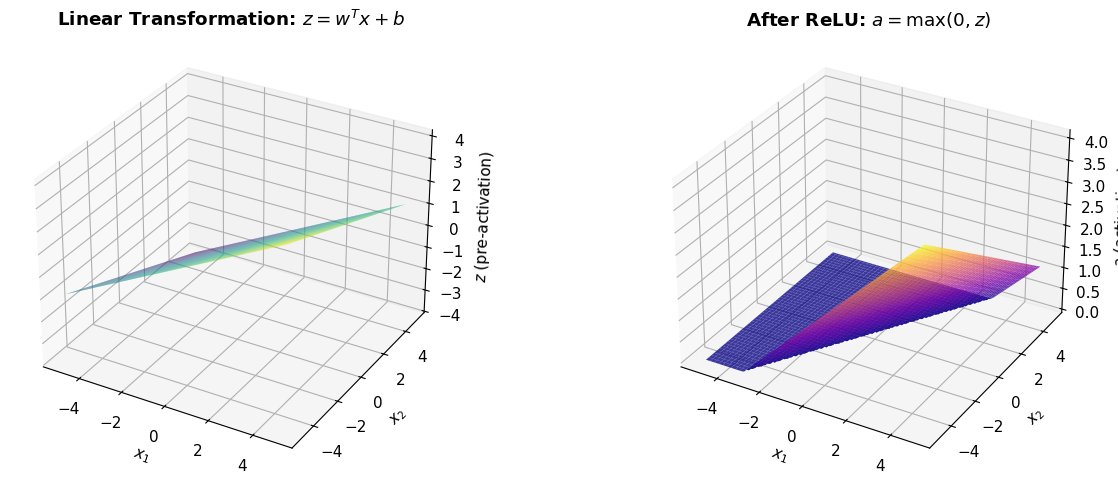

Notice: Linear transformation creates a plane, ReLU clips negative values to zero!


In [3]:
# Create a neuron with 2 inputs for visualization
neuron_2d = SingleNeuron(input_size=2)
neuron_2d.weights = np.array([0.5, -0.3])
neuron_2d.bias = 0.1

# Create a grid of inputs
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

# Compute neuron output for each point
Z = np.zeros_like(X1)
A = np.zeros_like(X1)

for i in range(len(x1)):
    for j in range(len(x2)):
        x_point = np.array([X1[j, i], X2[j, i]])
        z, a = neuron_2d.forward(x_point)
        Z[j, i] = z
        A[j, i] = a

# Plot pre-activation and activation
fig = plt.figure(figsize=(14, 5))

# Pre-activation (linear)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$z$ (pre-activation)')
ax1.set_title('Linear Transformation: $z = w^Tx + b$', fontweight='bold')

# Activation (with ReLU)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X1, X2, A, cmap='plasma', alpha=0.8)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_zlabel('$a$ (activation)')
ax2.set_title('After ReLU: $a = \max(0, z)$', fontweight='bold')

plt.tight_layout()
plt.show()

print("Notice: Linear transformation creates a plane, ReLU clips negative values to zero!")

### 🤔 Reflection Question

**Q:** What happens to the output when the input falls in the region where $z < 0$?

**Q:** Why is the ReLU output piecewise linear (half plane, half flat)?

## Part 5: Building Block 2 - A Layer of Neurons

One neuron is limited—it can only learn one simple pattern. To learn more complex patterns, we need **multiple neurons working in parallel**.

This is called a **layer**.

### What is a Layer?

> **A layer is a collection of neurons that all receive the same input and produce multiple outputs.**

### The Math

For a layer with $m$ neurons and $n$ inputs:

$$\mathbf{z} = W\mathbf{x} + \mathbf{b}$$
$$\mathbf{a} = f(\mathbf{z})$$

where:
- $W$ is an $(m \times n)$ weight matrix (each row = one neuron's weights)
- $\mathbf{x}$ is the input vector $(n \times 1)$
- $\mathbf{b}$ is the bias vector $(m \times 1)$
- $\mathbf{z}$ is the pre-activation vector $(m \times 1)$
- $\mathbf{a}$ is the activation vector $(m \times 1)$
- $f$ is applied element-wise

In [4]:
# Implement a layer from scratch
class Layer:
    def __init__(self, input_size, output_size):
        """A layer with multiple neurons.
        
        Args:
            input_size: number of input features
            output_size: number of neurons in this layer
        """
        # Initialize weights with small random values
        self.weights = np.random.randn(output_size, input_size) * 0.1
        self.bias = np.random.randn(output_size) * 0.1
    
    def forward(self, x):
        """Forward pass through the layer.
        
        Args:
            x: input vector (input_size,)
        
        Returns:
            z: pre-activation (output_size,)
            a: activation (output_size,)
        """
        # Linear transformation: z = Wx + b
        z = self.weights @ x + self.bias
        
        # Non-linear activation (ReLU)
        a = np.maximum(0, z)
        
        return z, a

# Create a layer: 3 inputs → 4 neurons
layer = Layer(input_size=3, output_size=4)

print("Layer Configuration:")
print(f"  Input size: 3")
print(f"  Output size (# neurons): 4")
print(f"  Weight matrix shape: {layer.weights.shape}")
print(f"  Bias vector shape: {layer.bias.shape}")
print(f"\nWeights:\n{layer.weights}")
print(f"\nBias: {layer.bias}")

Layer Configuration:
  Input size: 3
  Output size (# neurons): 4
  Weight matrix shape: (4, 3)
  Bias vector shape: (4,)

Weights:
[[ 0.07674347 -0.04694744  0.054256  ]
 [-0.04634177 -0.04657298  0.02419623]
 [-0.19132802 -0.17249178 -0.05622875]
 [-0.10128311  0.03142473 -0.09080241]]

Bias: [-0.14123037  0.14656488 -0.02257763  0.00675282]


Display the output.

In [5]:
# Test the layer with an input
x = np.array([1.0, 2.0, 3.0])
z, a = layer.forward(x)

print(f"Input: {x}")
print(f"\nPre-activation (z): {z}")
print(f"Activation (a): {a}")
print(f"\n✓ The layer transformed 3 inputs into 4 outputs!")

Input: [1. 2. 3.]

Pre-activation (z): [ 0.00438624  0.07966584 -0.72757548 -0.30408805]
Activation (a): [0.00438624 0.07966584 0.         0.        ]

✓ The layer transformed 3 inputs into 4 outputs!


### Key Insights: Layers

1. **Parallel processing**: Each neuron processes the same input independently
2. **Different features**: Each neuron learns to detect a different pattern/feature
3. **Dimensionality change**: A layer can change the size of the representation
4. **Matrix multiplication**: Efficient computation using vectorization

## Part 6: Understanding Layer Dimensions

Layer shapes can be confusing at first. Let's build strong intuitions!

In [6]:
# Visualize layer dimensions
def visualize_layer_dimensions(input_size, output_size):
    """Visualize how dimensions flow through a layer."""
    
    print("="*60)
    print(f"Layer: {input_size} inputs → {output_size} outputs")
    print("="*60)
    
    print(f"\nInput vector (x):     ({input_size},)")
    print(f"Weight matrix (W):    ({output_size}, {input_size})")
    print(f"Bias vector (b):      ({output_size},)")
    print(f"\nComputation: z = W @ x + b")
    print(f"  W @ x:              ({output_size}, {input_size}) @ ({input_size},) = ({output_size},)")
    print(f"  z = W @ x + b:      ({output_size},) + ({output_size},) = ({output_size},)")
    print(f"\nOutput vector (a):    ({output_size},)")
    
    # Calculate number of parameters
    num_params = output_size * input_size + output_size
    print(f"\nTotal parameters: {output_size} × {input_size} + {output_size} = {num_params}")
    print("  (weights + biases)")

# Try different layer configurations
visualize_layer_dimensions(3, 4)
print()
visualize_layer_dimensions(10, 5)
print()
visualize_layer_dimensions(100, 50)

Layer: 3 inputs → 4 outputs

Input vector (x):     (3,)
Weight matrix (W):    (4, 3)
Bias vector (b):      (4,)

Computation: z = W @ x + b
  W @ x:              (4, 3) @ (3,) = (4,)
  z = W @ x + b:      (4,) + (4,) = (4,)

Output vector (a):    (4,)

Total parameters: 4 × 3 + 4 = 16
  (weights + biases)

Layer: 10 inputs → 5 outputs

Input vector (x):     (10,)
Weight matrix (W):    (5, 10)
Bias vector (b):      (5,)

Computation: z = W @ x + b
  W @ x:              (5, 10) @ (10,) = (5,)
  z = W @ x + b:      (5,) + (5,) = (5,)

Output vector (a):    (5,)

Total parameters: 5 × 10 + 5 = 55
  (weights + biases)

Layer: 100 inputs → 50 outputs

Input vector (x):     (100,)
Weight matrix (W):    (50, 100)
Bias vector (b):      (50,)

Computation: z = W @ x + b
  W @ x:              (50, 100) @ (100,) = (50,)
  z = W @ x + b:      (50,) + (50,) = (50,)

Output vector (a):    (50,)

Total parameters: 50 × 100 + 50 = 5050
  (weights + biases)


### Parameter Counting Rule

For a layer with $n$ inputs and $m$ outputs:

**Number of parameters = $m \times n$ (weights) + $m$ (biases) = $m(n + 1)$**

This will be important later for understanding model size!

## Part 7: Building Block 3 - A Neural Network

Now for the magic: **stacking layers together**!

### What is a Neural Network?

> **A neural network is a sequence of layers where the output of one layer becomes the input to the next.**

### Example: 3-Layer Network

```
Input (10) → Layer 1 (20) → Layer 2 (15) → Layer 3 (5) → Output (5)
```

Each arrow represents a layer transformation!

In [7]:
# Implement a simple neural network
class SimpleNetwork:
    def __init__(self, layer_sizes):
        """A feedforward neural network.
        
        Args:
            layer_sizes: list of layer sizes [input, hidden1, hidden2, ..., output]
        """
        self.layers = []
        
        # Create layers
        for i in range(len(layer_sizes) - 1):
            layer = Layer(layer_sizes[i], layer_sizes[i+1])
            self.layers.append(layer)
        
        print(f"Created network with {len(self.layers)} layers:")
        for i, layer in enumerate(self.layers):
            print(f"  Layer {i+1}: {layer.weights.shape[1]} → {layer.weights.shape[0]}")
    
    def forward(self, x):
        """Forward pass through the entire network.
        
        Args:
            x: input vector
        
        Returns:
            output: final network output
            activations: list of activations from each layer
        """
        activations = [x]  # Store input as first activation
        
        # Pass through each layer
        current = x
        for i, layer in enumerate(self.layers):
            z, a = layer.forward(current)
            activations.append(a)
            current = a  # Output of this layer becomes input to next
            print(f"  After layer {i+1}: shape {a.shape}, values: {a[:3]}..." if len(a) > 3 else f"  After layer {i+1}: shape {a.shape}, values: {a}")
        
        return current, activations

# Create a 3-layer network
network = SimpleNetwork([10, 20, 15, 5])

# Test it
print("\nForward pass:")
x_test = np.random.randn(10)
print(f"  Input: shape {x_test.shape}")
output, activations = network.forward(x_test)
print(f"\nFinal output: shape {output.shape}, values: {output}")

Created network with 3 layers:
  Layer 1: 10 → 20
  Layer 2: 20 → 15
  Layer 3: 15 → 5

Forward pass:
  Input: shape (10,)
  After layer 1: shape (20,), values: [0.         0.23852625 0.34942807]...
  After layer 2: shape (15,), values: [0. 0. 0.]...
  After layer 3: shape (5,), values: [0. 0. 0.]...

Final output: shape (5,), values: [0.         0.         0.         0.06435516 0.02015855]


### Key Insight: Composition of Functions

A neural network is a **composition of functions**:

$$y = f_3(f_2(f_1(x)))$$

where each $f_i$ represents a layer transformation.

This is also called a **feedforward** network because information flows forward from input to output (no loops).

## Part 8: Why Stack Layers?

This is a crucial question: **Why not just use one big layer?**

### Reason 1: Hierarchical Feature Learning

Deep networks learn features at different levels of abstraction:

**Example: Image Recognition**
- Layer 1: Detects edges, corners, colors
- Layer 2: Combines edges into shapes (circles, rectangles)
- Layer 3: Combines shapes into parts (eyes, wheels, windows)
- Layer 4: Combines parts into objects (faces, cars, buildings)

### Reason 2: Parameter Efficiency

Let's compare parameter counts!

In [8]:
def count_parameters(layer_sizes):
    """Count total parameters in a network."""
    total = 0
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i+1]
        params = n_out * (n_in + 1)  # weights + biases
        total += params
        print(f"  Layer {i+1} ({n_in} → {n_out}): {params:,} parameters")
    return total

print("Deep network (100 → 50 → 25 → 10):")
params_deep = count_parameters([100, 50, 25, 10])
print(f"  Total: {params_deep:,} parameters\n")

print("Shallow network (100 → 10):")
params_shallow = count_parameters([100, 10])
print(f"  Total: {params_shallow:,} parameters\n")

print(f"Deep network uses {params_deep - params_shallow:,} MORE parameters")
print(f"  BUT can learn much more complex functions!\n")

# Now compare same-ish number of parameters
print("\nFair comparison (similar # parameters):")
print("\nDeep network (100 → 30 → 20 → 10):")
params_deep2 = count_parameters([100, 30, 20, 10])
print(f"  Total: {params_deep2:,} parameters")

print("\nShallow network (100 → 10):")
params_shallow2 = count_parameters([100, 10])
print(f"  Total: {params_shallow2:,} parameters")

print(f"\nWith similar parameter budgets, deep networks can learn\nmore complex patterns due to hierarchical composition!")

Deep network (100 → 50 → 25 → 10):
  Layer 1 (100 → 50): 5,050 parameters
  Layer 2 (50 → 25): 1,275 parameters
  Layer 3 (25 → 10): 260 parameters
  Total: 6,585 parameters

Shallow network (100 → 10):
  Layer 1 (100 → 10): 1,010 parameters
  Total: 1,010 parameters

Deep network uses 5,575 MORE parameters
  BUT can learn much more complex functions!


Fair comparison (similar # parameters):

Deep network (100 → 30 → 20 → 10):
  Layer 1 (100 → 30): 3,030 parameters
  Layer 2 (30 → 20): 620 parameters
  Layer 3 (20 → 10): 210 parameters
  Total: 3,860 parameters

Shallow network (100 → 10):
  Layer 1 (100 → 10): 1,010 parameters
  Total: 1,010 parameters

With similar parameter budgets, deep networks can learn
more complex patterns due to hierarchical composition!


### Reason 3: Compositionality

Complex patterns can be built from simpler ones:

- **Layer 1**: Learn simple features ("edges")
- **Layer 2**: Combine to form medium complexity ("textures", "shapes")
- **Layer 3**: Combine to form high complexity ("objects", "scenes")

This is more efficient than trying to learn everything at once!

## Part 9: Forward Pass Step-by-Step

Let's trace through a forward pass in excruciating detail to build perfect understanding.

In [9]:
# Create a tiny network for visualization
print("Creating a tiny network: 2 → 3 → 2\n")

# Layer 1: 2 inputs → 3 outputs
layer1 = Layer(2, 3)
layer1.weights = np.array([[0.5, -0.3],
                           [0.8, 0.2],
                           [-0.4, 0.6]])
layer1.bias = np.array([0.1, -0.1, 0.2])

# Layer 2: 3 inputs → 2 outputs
layer2 = Layer(3, 2)
layer2.weights = np.array([[0.7, -0.5, 0.3],
                           [-0.2, 0.4, 0.8]])
layer2.bias = np.array([0.0, 0.1])

print("Layer 1 weights:")
print(layer1.weights)
print(f"Layer 1 bias: {layer1.bias}\n")

print("Layer 2 weights:")
print(layer2.weights)
print(f"Layer 2 bias: {layer2.bias}\n")

Creating a tiny network: 2 → 3 → 2

Layer 1 weights:
[[ 0.5 -0.3]
 [ 0.8  0.2]
 [-0.4  0.6]]
Layer 1 bias: [ 0.1 -0.1  0.2]

Layer 2 weights:
[[ 0.7 -0.5  0.3]
 [-0.2  0.4  0.8]]
Layer 2 bias: [0.  0.1]



Show the final results.

In [10]:
# Input
x = np.array([1.0, 2.0])
print("="*60)
print("FORWARD PASS - STEP BY STEP")
print("="*60)

print(f"\nInput: {x}")
print(f"  Shape: {x.shape}")

# Layer 1
print("\n" + "-"*60)
print("LAYER 1: 2 → 3")
print("-"*60)

z1 = layer1.weights @ x + layer1.bias
print(f"\nLinear transformation: z1 = W1 @ x + b1")
print(f"  W1 @ x = \n{layer1.weights} @ {x}")
print(f"  = {layer1.weights @ x}")
print(f"  + b1 = {layer1.bias}")
print(f"  = z1 = {z1}")

a1 = np.maximum(0, z1)
print(f"\nActivation: a1 = ReLU(z1) = max(0, z1)")
print(f"  a1 = {a1}")
print(f"  Shape: {a1.shape}")

# Layer 2
print("\n" + "-"*60)
print("LAYER 2: 3 → 2")
print("-"*60)

z2 = layer2.weights @ a1 + layer2.bias
print(f"\nLinear transformation: z2 = W2 @ a1 + b2")
print(f"  W2 @ a1 = \n{layer2.weights} @ {a1}")
print(f"  = {layer2.weights @ a1}")
print(f"  + b2 = {layer2.bias}")
print(f"  = z2 = {z2}")

a2 = np.maximum(0, z2)
print(f"\nActivation: a2 = ReLU(z2) = max(0, z2)")
print(f"  a2 = {a2}")
print(f"  Shape: {a2.shape}")

# Final output
print("\n" + "="*60)
print("FINAL OUTPUT")
print("="*60)
print(f"\nInput was:  {x} (shape {x.shape})")
print(f"Output is:  {a2} (shape {a2.shape})")
print(f"\n✓ Successfully transformed 2D input to 2D output through hidden layer of 3 neurons!")

FORWARD PASS - STEP BY STEP

Input: [1. 2.]
  Shape: (2,)

------------------------------------------------------------
LAYER 1: 2 → 3
------------------------------------------------------------

Linear transformation: z1 = W1 @ x + b1
  W1 @ x = 
[[ 0.5 -0.3]
 [ 0.8  0.2]
 [-0.4  0.6]] @ [1. 2.]
  = [-0.1  1.2  0.8]
  + b1 = [ 0.1 -0.1  0.2]
  = z1 = [2.77555756e-17 1.10000000e+00 1.00000000e+00]

Activation: a1 = ReLU(z1) = max(0, z1)
  a1 = [2.77555756e-17 1.10000000e+00 1.00000000e+00]
  Shape: (3,)

------------------------------------------------------------
LAYER 2: 3 → 2
------------------------------------------------------------

Linear transformation: z2 = W2 @ a1 + b2
  W2 @ a1 = 
[[ 0.7 -0.5  0.3]
 [-0.2  0.4  0.8]] @ [2.77555756e-17 1.10000000e+00 1.00000000e+00]
  = [-0.25  1.24]
  + b2 = [0.  0.1]
  = z2 = [-0.25  1.34]

Activation: a2 = ReLU(z2) = max(0, z2)
  a2 = [0.   1.34]
  Shape: (2,)

FINAL OUTPUT

Input was:  [1. 2.] (shape (2,))
Output is:  [0.   1.34] (shape

### Key Takeaway: Forward Pass Algorithm

For each layer $l$:
1. Compute linear transformation: $\mathbf{z}^{[l]} = W^{[l]}\mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}$
2. Apply activation function: $\mathbf{a}^{[l]} = f(\mathbf{z}^{[l]})$
3. Pass $\mathbf{a}^{[l]}$ to next layer

Repeat until you reach the output layer!

## Part 10: Architecture Terminology

Let's learn the standard terminology for describing neural networks.

### Key Terms

**Input Layer**: The first layer (your raw data)
- Not usually counted as a "layer" since it has no parameters

**Hidden Layers**: Intermediate layers between input and output
- Called "hidden" because we don't directly observe their values
- These learn intermediate representations

**Output Layer**: The final layer producing predictions

**Width**: Number of neurons in a layer
- Wider layers = more capacity per layer

**Depth**: Number of layers in the network
- Deeper networks = more layers of abstraction

**Architecture**: The complete specification of layer sizes
- Example: "3-layer network with architecture [784, 128, 64, 10]"

**Parameters**: Total number of learnable weights and biases

In [11]:
def describe_architecture(layer_sizes):
    """Describe a neural network architecture."""
    
    print("="*70)
    print(f"NETWORK ARCHITECTURE: {layer_sizes}")
    print("="*70)
    
    # Basic stats
    n_layers = len(layer_sizes) - 1  # Don't count input as a layer
    print(f"\nDepth: {n_layers} layers (not counting input)")
    
    # Layer breakdown
    print(f"\nInput size: {layer_sizes[0]}")
    
    if n_layers > 1:
        print(f"Hidden layers: {n_layers - 1}")
        for i in range(1, n_layers):
            print(f"  Hidden layer {i}: {layer_sizes[i]} neurons (width={layer_sizes[i]})")
    
    print(f"Output layer: {layer_sizes[-1]} neurons")
    
    # Parameters
    print(f"\nParameter breakdown:")
    total_params = 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i+1]
        params = n_out * (n_in + 1)
        total_params += params
        print(f"  Layer {i+1}: {n_in} → {n_out} = {params:,} parameters")
    
    print(f"\nTotal parameters: {total_params:,}")
    
    # Max width
    max_width = max(layer_sizes[1:-1]) if n_layers > 1 else layer_sizes[-1]
    print(f"Maximum width: {max_width}")
    
    return total_params

# Describe some common architectures
describe_architecture([784, 128, 10])
print("\n")
describe_architecture([784, 256, 128, 64, 10])
print("\n")
describe_architecture([100, 50, 50, 50, 10])

NETWORK ARCHITECTURE: [784, 128, 10]

Depth: 2 layers (not counting input)

Input size: 784
Hidden layers: 1
  Hidden layer 1: 128 neurons (width=128)
Output layer: 10 neurons

Parameter breakdown:
  Layer 1: 784 → 128 = 100,480 parameters
  Layer 2: 128 → 10 = 1,290 parameters

Total parameters: 101,770
Maximum width: 128


NETWORK ARCHITECTURE: [784, 256, 128, 64, 10]

Depth: 4 layers (not counting input)

Input size: 784
Hidden layers: 3
  Hidden layer 1: 256 neurons (width=256)
  Hidden layer 2: 128 neurons (width=128)
  Hidden layer 3: 64 neurons (width=64)
Output layer: 10 neurons

Parameter breakdown:
  Layer 1: 784 → 256 = 200,960 parameters
  Layer 2: 256 → 128 = 32,896 parameters
  Layer 3: 128 → 64 = 8,256 parameters
  Layer 4: 64 → 10 = 650 parameters

Total parameters: 242,762
Maximum width: 256


NETWORK ARCHITECTURE: [100, 50, 50, 50, 10]

Depth: 4 layers (not counting input)

Input size: 100
Hidden layers: 3
  Hidden layer 1: 50 neurons (width=50)
  Hidden layer 2: 50 n

10660

### 🤔 Reflection Questions

**Q1:** Which has more parameters: a wide shallow network or a narrow deep network?

**Q2:** For MNIST (28×28 images = 784 pixels), why is the input size 784?

**Q3:** For 10-class classification, why is the output size 10?

## Part 11: Visualizing Network Architecture

Let's create a visual representation of neural network architectures.

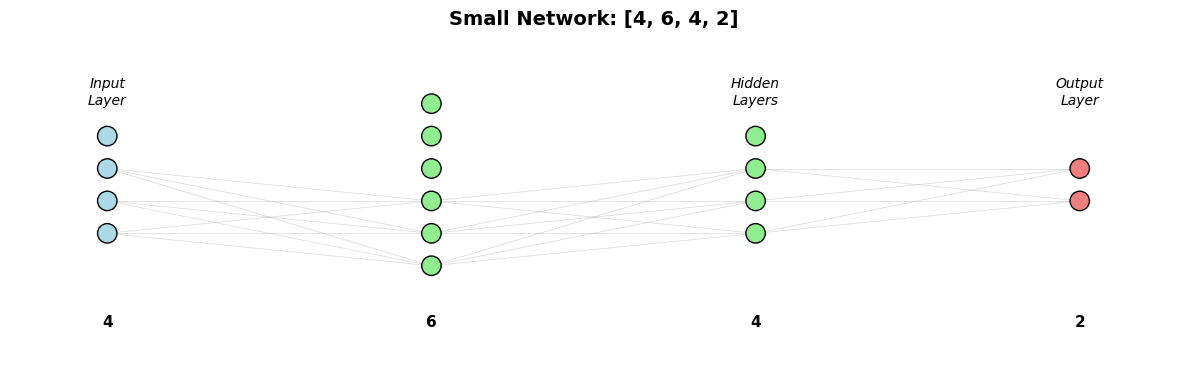

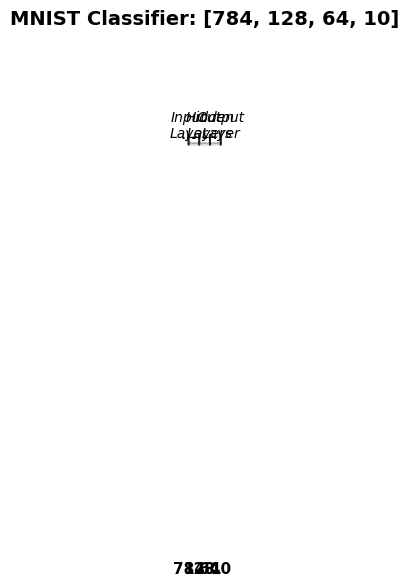

In [12]:
def plot_network_architecture(layer_sizes, title="Neural Network Architecture"):
    """Plot a visual diagram of the network."""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Configuration
    layer_spacing = 1.0
    max_neurons_to_show = 10
    
    # Draw each layer
    for i, size in enumerate(layer_sizes):
        x = i * layer_spacing
        
        # Limit neurons shown for large layers
        neurons_to_show = min(size, max_neurons_to_show)
        show_dots = size > max_neurons_to_show
        
        # Vertical spacing
        max_size = max(layer_sizes)
        y_offset = (max_size - neurons_to_show) / 2 * 0.1
        
        # Draw neurons
        for j in range(neurons_to_show):
            y = j * 0.1 + y_offset
            
            # Choose color
            if i == 0:
                color = 'lightblue'
                label = 'Input' if j == 0 else ''
            elif i == len(layer_sizes) - 1:
                color = 'lightcoral'
                label = 'Output' if j == 0 else ''
            else:
                color = 'lightgreen'
                label = 'Hidden' if j == 0 and i == 1 else ''
            
            circle = plt.Circle((x, y), 0.03, color=color, ec='black', zorder=4)
            ax.add_patch(circle)
        
        # Show "..." if truncated
        if show_dots:
            y = neurons_to_show * 0.1 + y_offset
            ax.text(x, y + 0.05, '...', ha='center', va='center', fontsize=12)
        
        # Layer label
        ax.text(x, -0.15, f'{size}', ha='center', va='top', fontsize=11, fontweight='bold')
        
        # Draw connections to next layer
        if i < len(layer_sizes) - 1:
            next_size = min(layer_sizes[i+1], max_neurons_to_show)
            next_y_offset = (max_size - next_size) / 2 * 0.1
            
            # Draw sample connections (not all, would be too messy)
            for j in range(min(3, neurons_to_show)):
                y1 = j * 0.1 + y_offset
                for k in range(min(3, next_size)):
                    y2 = k * 0.1 + next_y_offset
                    ax.plot([x, x + layer_spacing], [y1, y2], 'gray', alpha=0.3, linewidth=0.5, zorder=1)
    
    # Labels
    ax.text(0, max(layer_sizes) * 0.1 * 0.5 + 0.2, 'Input\nLayer', ha='center', fontsize=10, style='italic')
    if len(layer_sizes) > 2:
        mid_idx = len(layer_sizes) // 2
        ax.text(mid_idx * layer_spacing, max(layer_sizes) * 0.1 * 0.5 + 0.2, 'Hidden\nLayers', ha='center', fontsize=10, style='italic')
    ax.text((len(layer_sizes)-1) * layer_spacing, max(layer_sizes) * 0.1 * 0.5 + 0.2, 'Output\nLayer', ha='center', fontsize=10, style='italic')
    
    ax.set_xlim(-0.3, (len(layer_sizes)-1) * layer_spacing + 0.3)
    ax.set_ylim(-0.3, max(layer_sizes) * 0.1 * 0.6 + 0.3)
    ax.axis('off')
    ax.set_aspect('equal')
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Visualize different architectures
plot_network_architecture([4, 6, 4, 2], "Small Network: [4, 6, 4, 2]")
plot_network_architecture([784, 128, 64, 10], "MNIST Classifier: [784, 128, 64, 10]")

## Part 12: The Universal Approximation Theorem

Now for one of the most profound results in neural network theory!

### The Theorem (Informal)

> **A neural network with even just ONE hidden layer can approximate ANY continuous function, given enough neurons.**

Let that sink in. With enough width, a 2-layer network (input → hidden → output) can approximate:
- Polynomials
- Trigonometric functions
- Exponentials
- Any smooth function you can imagine!

### What Does This Mean?

1. **Theoretical power**: Neural networks are incredibly expressive
2. **Not practical**: "Enough neurons" might mean millions or billions
3. **Deep is better**: Deep networks can approximate functions more efficiently

### The Intuition

Think of it like building a function from Lego blocks:
- Each neuron is a building block (piecewise linear due to ReLU)
- With enough blocks, you can approximate any shape
- More blocks = better approximation

## Part 13: Demonstrating Universal Approximation

Let's see this in action by approximating different functions!

In [13]:
# Create a simple PyTorch network for approximation
class Approximator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def train_approximator(target_func, hidden_size=50, epochs=2000):
    """Train a network to approximate a target function."""
    
    # Generate training data
    x_train = torch.linspace(-3, 3, 200).reshape(-1, 1)
    y_train = target_func(x_train)
    
    # Create model
    model = Approximator(hidden_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    # Train
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    
    return model, x_train, y_train

print("Training neural network to approximate sin(x)...\n")
model_sin, x_train, y_train = train_approximator(torch.sin, hidden_size=20)
print("\n✓ Training complete!")

Training neural network to approximate sin(x)...



  Epoch 500/2000, Loss: 0.000248


  Epoch 1000/2000, Loss: 0.000079


  Epoch 1500/2000, Loss: 0.000060


  Epoch 2000/2000, Loss: 0.000052

✓ Training complete!


Visualize the results with multiple plots for comparison.

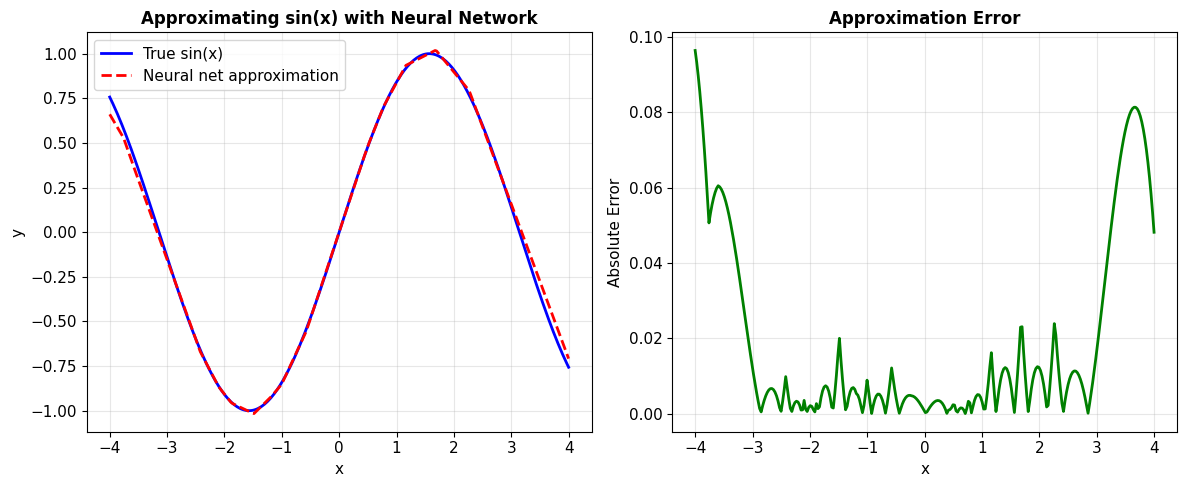

Maximum error: 0.096467
Mean error: 0.018401


In [14]:
# Visualize the approximation
model_sin.eval()
with torch.no_grad():
    x_test = torch.linspace(-4, 4, 300).reshape(-1, 1).to(device)
    y_true = torch.sin(x_test)
    y_pred = model_sin(x_test)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_test.cpu(), y_true.cpu(), 'b-', linewidth=2, label='True sin(x)')
plt.plot(x_test.cpu(), y_pred.cpu(), 'r--', linewidth=2, label='Neural net approximation')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.title('Approximating sin(x) with Neural Network', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
error = (y_true - y_pred).abs().cpu()
plt.plot(x_test.cpu(), error, 'g-', linewidth=2)
plt.xlabel('x', fontsize=11)
plt.ylabel('Absolute Error', fontsize=11)
plt.title('Approximation Error', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Maximum error: {error.max():.6f}")
print(f"Mean error: {error.mean():.6f}")

### Try Different Functions!

Let's approximate more complex functions.


Training to approximate sin(x)...


  Epoch 500/1000, Loss: 0.000085


  Epoch 1000/1000, Loss: 0.000044

Training to approximate sin(x) + 0.5cos(2x) + 0.3x...


  Epoch 500/1000, Loss: 0.000787


  Epoch 1000/1000, Loss: 0.000587

Training to approximate |x| - 1...


  Epoch 500/1000, Loss: 0.000193


  Epoch 1000/1000, Loss: 0.000016


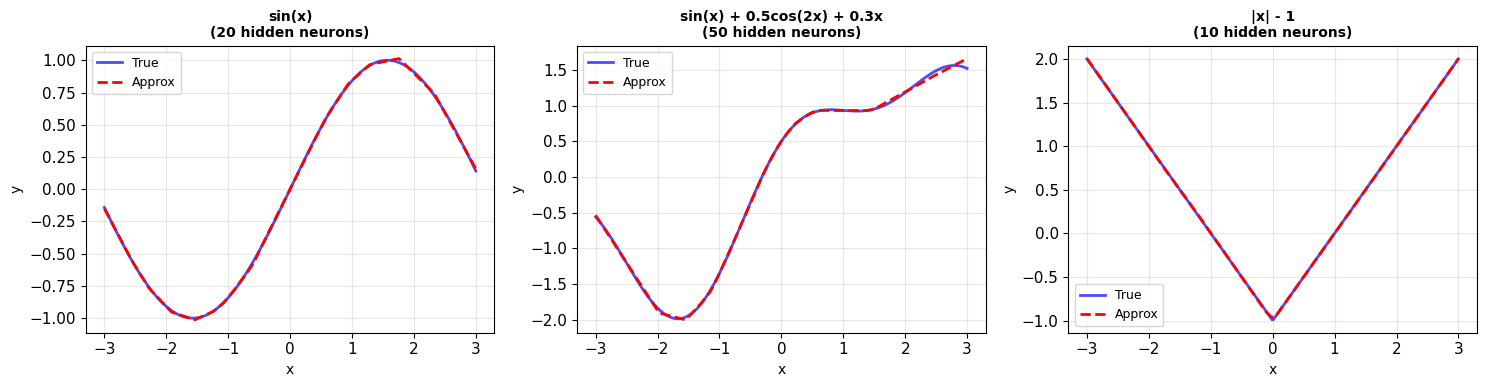


✓ Neural networks can approximate diverse functions!


In [15]:
# Define several target functions
def complex_func(x):
    return torch.sin(x) + 0.5 * torch.cos(2*x) + 0.3 * x

def step_func(x):
    return torch.sign(torch.sin(3*x))

def abs_func(x):
    return torch.abs(x) - 1

# Train networks to approximate each
functions = [
    (torch.sin, "sin(x)", 20),
    (complex_func, "sin(x) + 0.5cos(2x) + 0.3x", 50),
    (abs_func, "|x| - 1", 10)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (func, name, hidden_size) in enumerate(functions):
    print(f"\nTraining to approximate {name}...")
    model, _, _ = train_approximator(func, hidden_size=hidden_size, epochs=1000)
    
    # Test
    model.eval()
    with torch.no_grad():
        x_test = torch.linspace(-3, 3, 300).reshape(-1, 1).to(device)
        y_true = func(x_test)
        y_pred = model(x_test)
    
    # Plot
    ax = axes[idx]
    ax.plot(x_test.cpu(), y_true.cpu(), 'b-', linewidth=2, label='True', alpha=0.7)
    ax.plot(x_test.cpu(), y_pred.cpu(), 'r--', linewidth=2, label='Approx')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.set_title(f'{name}\n({hidden_size} hidden neurons)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Neural networks can approximate diverse functions!")

## Part 14: Width vs Depth

The Universal Approximation Theorem says we can use one wide layer. But in practice, **deep networks work much better**.

### Why Deep Works Better

1. **Parameter efficiency**: Deep networks need fewer parameters for same expressiveness
2. **Hierarchical features**: Naturally learn compositional representations
3. **Optimization**: Surprisingly, often easier to train (with modern techniques)
4. **Generalization**: Better transfer of learned features

Let's compare!

In [16]:
# Create wide vs deep networks with similar parameter counts
class WideNetwork(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        return self.net(x)

class DeepNetwork(nn.Module):
    def __init__(self, width, depth):
        super().__init__()
        layers = [nn.Linear(1, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.extend([nn.Linear(width, width), nn.ReLU()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# Compare architectures
wide_net = WideNetwork(100)
deep_net = DeepNetwork(20, 4)  # 4 layers, width 20

wide_params = sum(p.numel() for p in wide_net.parameters())
deep_params = sum(p.numel() for p in deep_net.parameters())

print("WIDE Network (1 → 100 → 1):")
print(f"  Parameters: {wide_params:,}")
print(f"  Depth: 2 layers")

print("\nDEEP Network (1 → 20 → 20 → 20 → 1):")
print(f"  Parameters: {deep_params:,}")
print(f"  Depth: 4 layers")

print(f"\nParameter ratio: {wide_params/deep_params:.2f}x more in wide network")
print("\nIn practice, the deep network would likely perform better!")

WIDE Network (1 → 100 → 1):
  Parameters: 301
  Depth: 2 layers

DEEP Network (1 → 20 → 20 → 20 → 1):
  Parameters: 901
  Depth: 4 layers

Parameter ratio: 0.33x more in wide network

In practice, the deep network would likely perform better!


## Part 15: Practical Considerations

Now that we understand what neural networks are, let's discuss practical aspects.

### Choosing Architecture

**Rules of thumb**:

1. **Start simple**: Begin with 1-2 hidden layers
2. **Increase gradually**: Add layers/neurons if underfitting
3. **Common patterns**:
   - Decreasing width: [784, 256, 128, 64, 10]
   - Constant width: [100, 50, 50, 50, 10]
   - Bottleneck: [784, 128, 32, 128, 784] (autoencoders)

4. **Output layer size**: Determined by task
   - Regression: 1 neuron
   - Binary classification: 1 neuron (sigmoid)
   - Multi-class: C neurons (softmax), where C = # classes

### Activation Functions

**Hidden layers**: Almost always ReLU or variants (Leaky ReLU, ELU)
- Fast to compute
- Helps with vanishing gradient problem

**Output layer**: Depends on task
- Regression: None (linear)
- Binary classification: Sigmoid
- Multi-class classification: Softmax

### Common Mistakes

❌ **Too deep too soon**: Start simple!
❌ **Wrong output activation**: Softmax for regression won't work
❌ **Forgetting bias terms**: They're important!
❌ **Random architecture**: Think about the task

## Part 16: PyTorch Implementation

Let's see how to build networks in PyTorch (the industry standard).

In [17]:
# Method 1: Sequential API (simple, clean)
model_sequential = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print("Method 1: Sequential API")
print(model_sequential)
print(f"\nTotal parameters: {sum(p.numel() for p in model_sequential.parameters()):,}")

Method 1: Sequential API
Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 109,386


Define the CustomNetwork architecture.

In [18]:
# Method 2: Custom Module (flexible, preferred for complex models)
class CustomNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        """Define the forward pass."""
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No activation on output (will use with loss function)
        return x

model_custom = CustomNetwork(784, [128, 64], 10)

print("Method 2: Custom Module")
print(model_custom)
print(f"\nTotal parameters: {sum(p.numel() for p in model_custom.parameters()):,}")

Method 2: Custom Module
CustomNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 109,386


Display the output.

In [19]:
# Test the model with random input
batch_size = 32
x_test = torch.randn(batch_size, 784).to(device)

model_custom.to(device)
output = model_custom(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"\nOutput for first sample: {output[0]}")
print("\n✓ Forward pass successful!")

Input shape: torch.Size([32, 784])
Output shape: torch.Size([32, 10])

Output for first sample: tensor([ 0.0285,  0.1030,  0.0024,  0.0728, -0.0666, -0.2001,  0.1419, -0.0169,
        -0.1307,  0.2314], grad_fn=<SelectBackward0>)

✓ Forward pass successful!


## Part 17: Inspecting Network Parameters

Let's look inside the network and see the actual parameters.

In [20]:
# Inspect parameters
print("Network Parameters:\n")

for name, param in model_custom.named_parameters():
    print(f"{name:20s} | Shape: {str(param.shape):20s} | # params: {param.numel():,}")

print("\n" + "="*70)
total = sum(p.numel() for p in model_custom.parameters())
print(f"Total parameters: {total:,}")
print("="*70)

# Look at actual weight values
print("\nFirst layer weights (first 5 neurons, first 10 weights each):")
print(model_custom.fc1.weight[:5, :10])

print("\nFirst layer biases (first 10):")
print(model_custom.fc1.bias[:10])

Network Parameters:

fc1.weight           | Shape: torch.Size([128, 784]) | # params: 100,352
fc1.bias             | Shape: torch.Size([128])    | # params: 128
fc2.weight           | Shape: torch.Size([64, 128]) | # params: 8,192
fc2.bias             | Shape: torch.Size([64])     | # params: 64
fc3.weight           | Shape: torch.Size([10, 64]) | # params: 640
fc3.bias             | Shape: torch.Size([10])     | # params: 10

Total parameters: 109,386

First layer weights (first 5 neurons, first 10 weights each):
tensor([[-0.0238,  0.0193, -0.0031,  0.0267,  0.0250, -0.0170, -0.0232,  0.0252,
          0.0176, -0.0276],
        [ 0.0116, -0.0248,  0.0263, -0.0037, -0.0119,  0.0153,  0.0343, -0.0202,
          0.0165, -0.0122],
        [-0.0056, -0.0345, -0.0325,  0.0227, -0.0233, -0.0025,  0.0328,  0.0324,
          0.0272, -0.0103],
        [-0.0164, -0.0136, -0.0049, -0.0241, -0.0234,  0.0072,  0.0342,  0.0334,
         -0.0200, -0.0139],
        [ 0.0117,  0.0123, -0.0264,  0.0258,

### Key Insight: What Gets Learned

During training (which we'll learn in the backpropagation notebook):
- These weight and bias values get updated
- The network learns to adjust them to minimize prediction error
- Different tasks lead to different learned values

**The magic of deep learning**: We don't manually set these values—the network learns them automatically from data!

## Part 18: Summary & Key Takeaways

Congratulations! You now understand what neural networks actually are.

### 🎯 Core Concepts Mastered

**1. Single Neuron**
- Linear transformation: $z = \mathbf{w}^T\mathbf{x} + b$
- Non-linear activation: $a = f(z)$
- Combines inputs with learned weights

**2. Layer**
- Multiple neurons in parallel
- Matrix form: $\mathbf{z} = W\mathbf{x} + \mathbf{b}$
- Changes dimensionality: $n$ inputs → $m$ outputs
- Parameters: $m(n + 1)$ total

**3. Neural Network**
- Composition of layers: $y = f_L(...f_2(f_1(x)))$
- Forward pass: sequentially apply transformations
- Learns hierarchical features automatically

**4. Architecture**
- **Width**: neurons per layer (capacity)
- **Depth**: number of layers (abstraction)
- **Parameters**: total learnable weights and biases
- Deep > Wide (usually more efficient)

**5. Universal Approximation**
- Even one hidden layer can approximate any function
- But deep networks do it more efficiently
- Theory says "can approximate", practice requires right architecture

### 🚀 What's Next?

You now understand **what** a neural network is and **how** the forward pass works.

Next steps:
1. **Backpropagation** (z2h-01-backprop.ipynb): How to train networks
2. **Optimization**: Gradient descent, learning rates, momentum
3. **Regularization**: Preventing overfitting
4. **Specialized architectures**: CNNs, RNNs, Transformers

### 💡 The Big Picture

Neural networks are:
- **Not magic**: Just compositions of simple mathematical functions
- **Powerful**: Can learn incredibly complex patterns from data
- **Flexible**: Same framework works for images, text, audio, games
- **Trainable**: Automatic learning through gradient descent (next notebook!)

### 🤔 Final Reflection Questions

1. Can you explain to someone what a layer does in plain English?
2. Why do we need non-linear activation functions?
3. What's the difference between network width and depth?
4. Why are deep networks generally better than shallow ones?
5. What determines the output layer size for a classification task?

---

**Well done!** 🎉 You've built solid foundations for understanding neural networks. The forward pass is half the story—now you're ready to learn backpropagation!